In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/home/k-k/GenAI-Project/data/train.csv')

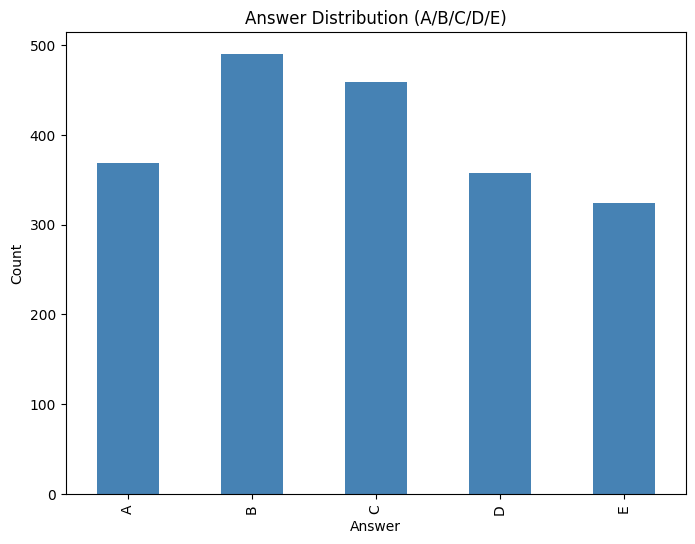

In [3]:
plt.figure(figsize=(8,6))
df['answer'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Answer Distribution (A/B/C/D/E)')
plt.xlabel('Answer')
plt.ylabel('Count')
plt.show()

In [7]:
df['prompt_len'] = df['prompt'].apply(lambda x: len(x.split()))

# Option lengths
for col in ['A', 'B', 'C', 'D', 'E']:
    df[f'{col}_len'] = df[col].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)

print("\nPrompt word length stats:")
print(df['prompt_len'].describe())


Prompt word length stats:
count    2000.00000
mean       18.14650
std         6.78189
min         3.00000
25%        14.00000
50%        17.00000
75%        22.00000
max        51.00000
Name: prompt_len, dtype: float64


In [ ]:
# Check most common answer
most_common = df['answer'].value_counts().idxmax()
print(f"Most common answer: {most_common}")

# Load sample submission
sub = pd.read_csv('/home/k-k/GenAI-Project/data/sample_submission.csv')
print(sub.head())
print(sub.columns.tolist())

# Fill with majority class
sub['Prediction'] = most_common
sub.to_csv('submission.csv', index=False)
print("Baseline submission saved!")

Most common answer: B
   ID Prediction
0   1      A B C
1   2      A B C
2   3      A B C
3   4      A B C
4   5      A B C
['ID', 'Prediction']
Baseline submission saved!
